
---

# 🎯 ***`Bias-Variance Trade-off in Machine Learning for Data Science`***  

### ✅ **What is the Bias-Variance Trade-off?**  

📌 The **Bias-Variance Trade-off** describes the balance between **underfitting (high bias)** and **overfitting (high variance)** in machine learning models.  

✔ **High Bias (Underfitting)** → Model is too simple, fails to capture patterns.  
✔ **High Variance (Overfitting)** → Model is too complex, memorizes noise instead of learning patterns.  
✔ **Goal:** Find a **balance** where the model generalizes well on unseen data.  

---

## 📊 **1. Understanding Bias & Variance**  

| **Concept**  | **Definition** | **Effect on Model** | **Example** |
|--------------|---------------|---------------------|-------------|
| **Bias**  | Error due to incorrect assumptions | Underfitting | Model is too simple (e.g., Linear Regression on non-linear data) |
| **Variance** | Error due to sensitivity to small changes in data | Overfitting | Model memorizes noise instead of learning patterns |

📌 **Total Error = Bias² + Variance + Irreducible Error**  

$
\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Noise}
$

### 🔹 **Bias & Variance in a Graphical View**  
- **High Bias:** Predictions far from actual values (Underfitting).  
- **High Variance:** Predictions vary widely on different datasets (Overfitting).  
- **Balanced Model:** Optimal performance with good generalization.  

---

## 📉 **2. Graphical Representation of Bias-Variance Trade-off**  

📌 **Effect of Model Complexity on Error**  
- **Low Complexity → `High Bias, Low Variance (Underfitting)`**  
- **High Complexity → `Low Bias, High Variance (Overfitting)`**  
- **Optimal Complexity → Balanced Bias & Variance (Best Fit)**  

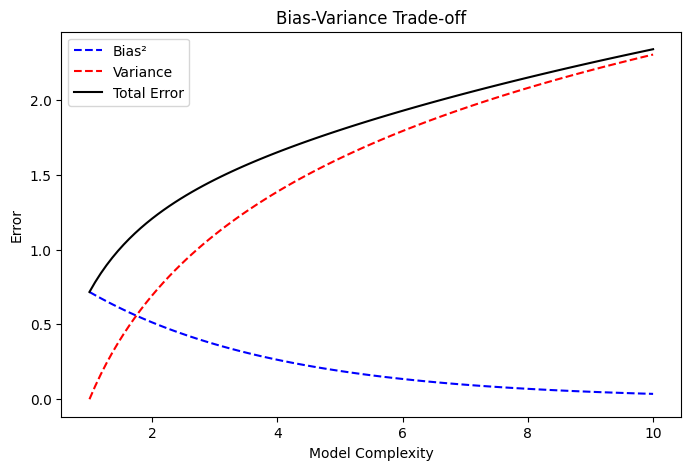

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 100)
y = np.sin(X) + np.random.normal(scale=0.3, size=100)  # Adding noise

# Plot bias-variance tradeoff curve
complexity = np.linspace(1, 10, 100)
bias = np.exp(-complexity / 3)
variance = np.log(complexity)
total_error = bias + variance

plt.figure(figsize=(8, 5))
plt.plot(complexity, bias, label="Bias²", linestyle="dashed", color="blue")
plt.plot(complexity, variance, label="Variance", linestyle="dashed", color="red")
plt.plot(complexity, total_error, label="Total Error", color="black")
plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Trade-off")
plt.legend()
plt.show()

📌 **Observations:**  
✔ **Left Side (Underfitting)** → High Bias, Low Variance.  
✔ **Right Side (Overfitting)** → Low Bias, High Variance.  
✔ **Middle (Optimal Model Complexity)** → Balance between Bias & Variance.  

---

## 📏 **3. How to Detect Bias vs. Variance?**  

📌 **Look at Train & Test Performance**  
| **Scenario** | **Train Error** | **Test Error** | **Issue** |
|-------------|---------------|-------------|-------------|
| **High Bias (Underfitting)** | **High** | **High** | Model is too simple, poor accuracy on both train & test data. |
| **High Variance (Overfitting)** | **Low** | **High** | Model memorizes training data but fails on test data. |
| **Balanced Model (Good Fit)** | **Low** | **Low** | Model generalizes well on unseen data. |

---

## 🏹 **4. Bias-Variance Trade-off in Different ML Models**  

📌 **Simple models have high bias, complex models have high variance.**  

| **Model** | **Bias** | **Variance** | **Best For** |
|-----------|---------|------------|-------------|
| **Linear Regression** | High | Low | When data has a linear relationship |
| **Polynomial Regression (High Degree)** | Low | High | When data is complex, but risks overfitting |
| **Decision Trees (Deep Trees)** | Low | High | Can overfit if not pruned |
| **Random Forest** | Medium | Medium | Reduces variance using multiple trees |
| **Neural Networks** | Low | High | Needs regularization to avoid overfitting |

📌 **Model Complexity Trade-off:**  
✔ **Too Simple → Underfits**  
✔ **Too Complex → Overfits**  
✔ **Optimal Model → Balances Bias & Variance**  

---

## 🛠 **5. How to Reduce Bias & Variance?**  

### ✅ **Reducing High Bias (Underfitting)**
✔ **Increase model complexity** (e.g., use Polynomial Regression instead of Linear Regression).  
✔ **Add more relevant features** to improve learning.  
✔ **Reduce regularization strength** (e.g., decrease `lambda` in Ridge/Lasso Regression).  
✔ **Use more powerful models** (e.g., Neural Networks, Random Forest).  

### ✅ **Reducing High Variance (Overfitting)**
✔ **Collect more training data** (helps models generalize better).  
✔ **Use Regularization techniques** (e.g., Ridge (L2), Lasso (L1) Regression).  
✔ **Use Ensemble Learning** (e.g., Random Forest, Bagging).  
✔ **Feature Selection** → Remove irrelevant/noisy features.  
✔ **Cross-validation (e.g., k-Fold CV)** to detect overfitting.  

---

## 🎯 **6. Practical Example: Handling Bias-Variance in Polynomial Regression**  

Degree 1 - Test MSE: 0.4777
Degree 3 - Test MSE: 0.3273
Degree 10 - Test MSE: 0.0595


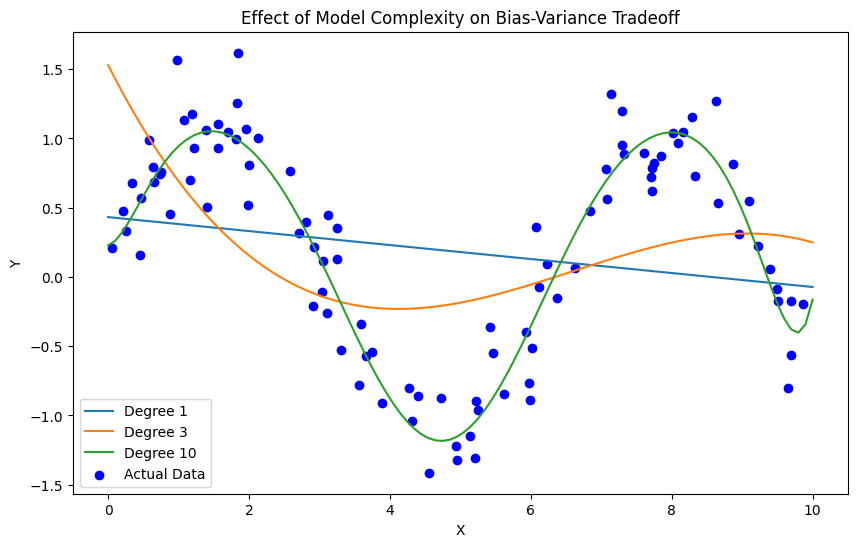

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate Synthetic Data
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # Feature
y = np.sin(X).ravel() + np.random.normal(0, 0.3, size=100)  # Target with noise

# Split into Train-Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Models with Different Degrees
degrees = [1, 3, 10]
plt.figure(figsize=(10, 6))

for d in degrees:
    poly_reg = Pipeline([
        ('poly_features', PolynomialFeatures(degree=d)),
        ('linear_model', LinearRegression())
    ])
    
    poly_reg.fit(X_train, y_train)
    y_pred = poly_reg.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    print(f"Degree {d} - Test MSE: {mse:.4f}")

    # Plot Predictions
    X_pred = np.linspace(0, 10, 100).reshape(-1, 1)
    y_pred_curve = poly_reg.predict(X_pred)
    plt.plot(X_pred, y_pred_curve, label=f"Degree {d}")

# Scatter Plot
plt.scatter(X, y, color='blue', label="Actual Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Effect of Model Complexity on Bias-Variance Tradeoff")
plt.legend()
plt.show()


📌 **Observations:**  
✔ **Degree 1 (Linear Model)** → Underfits (High Bias).  
✔ **Degree 3** → Best Fit (Balances Bias & Variance).  
✔ **Degree 10** → Overfits (High Variance).  

---

## 🏆 **7. Key Takeaways**  

✔ **Bias is error due to incorrect assumptions, Variance is error due to sensitivity to small changes.**  
✔ **Low Bias, High Variance** → Overfitting.  
✔ **High Bias, Low Variance** → Underfitting.  
✔ **Use Regularization, Cross-Validation, and Feature Selection to handle Bias-Variance Tradeoff.**  
✔ **Optimal Model Complexity balances Bias and Variance for best generalization.**  

💡 **Pro Tip:** Always use **Train-Test Validation + Cross-Validation** to detect **Bias-Variance issues** before deploying models.

---